In [ ]:
!unzip playground-series-s5e9.zip

Archive:  playground-series-s5e9.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
print(train.shape)
print(train.isnull().sum())
print(train.describe())


(524164, 11)
id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64
                  id    RhythmScore  AudioLoudness   VocalContent  \
count  524164.000000  524164.000000  524164.000000  524164.000000   
mean   262081.500000       0.632843      -8.379014       0.074443   
std    151313.257586       0.156899       4.616221       0.049939   
min         0.000000       0.076900     -27.509725       0.023500   
25%    131040.750000       0.515850     -11.551933       0.023500   
50%    262081.500000       0.634686      -8.252499       0.066425   
75%    393122.250000       0.739179      -4.912298       0.107343   
max    524163.000000       0.975000      -1.357000       0.256401   

       Acou

In [ ]:
#generator a  ydata-profiling report
!pip install ydata-profiling

import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

df = train.copy()
profile = ProfileReport(df, title="Profiling Report")
profile.to_file("init_eda_report.html")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=f54851a47bfcc9fdd36a1a673c1cdb968bdaf5d68108ad88877f0d8f397fa2f2
  Stored in directory: /root/.cache/pip/wheels/5f/d4/d7/4189b07b5902ee9f3ce0dbb14909fbe8037c39d6c63ffd49c9
Successfully built htmlmin
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
     

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:03<00:00,  2.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

特征重要性分析

In [ ]:
#分好特征和标签
df = train.copy()
X = df.drop(['id','BeatsPerMinute'], axis=1)
y = df['BeatsPerMinute']

In [40]:
# 训练随机森林
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 获取特征重要性
importances = rf.feature_importances_

# 可视化
plt.barh(X.columns, importances)
plt.xlabel('Importance')
plt.show()

KeyboardInterrupt: 

In [ ]:
# 训练xgboost基线
rf = XGBRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    n_jobs=-1,
    objective='reg:squarederror'
)
rf.fit(X, y)

# 获取特征重要性
importances = rf.feature_importances_

# 可视化
plt.barh(X.columns, importances)
plt.xlabel('Importance')
plt.show()

In [ ]:
#初步eda
  #节奏乐谱分布比较怪，0.6-0.7是峰值且数量多，接近1数量也多
  #音频响度-1.37数量超11%，其他的分布均匀
  #声音内容0.02的占比超过30%
  #音质无限接近0的超过17%，音质接近1的只有1%
  #器乐谱无限接近0的占比超过33%
  #现场表演可能性0.02的占比超过16.1%
  #情绪分分布偏中间、右尾略重，左右尾各接近4%
  #歌曲时长呈高斯分布
  #能量分布平均，能量和音质呈负相关，能量和音响强度呈正相关
  #target节拍呈高斯分布
  #数据无重复行，无缺失值，数据量不大可以尝试少量特征工程观察拟合情况

#假设
  #采集/处理质量不高
  #少人声重乐器歌曲偏多
  #energy可能极为重要

#基线证明假设
  #随机森林重要性提供单个特征贡献。测试,能量，曲目时长和节奏乐谱的分数最高
  #xgboost重要性测试提供交互特征贡献。几个特征非常平均分时相似


**autogluon 测试**

In [25]:
from autogluon.tabular import TabularDataset, TabularPredictor

df = train.copy()
data = df.drop('id', axis=1)
X_train, y_test = train_test_split(data, test_size=0.2, random_state=42)


model = TabularPredictor(label='BeatsPerMinute',problem_type='regression',eval_metric='rmse')
model.fit(train_data = X_train,time_limit=600)

No path specified. Models will be saved in: "AutogluonModels/ag-20250908_191637"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
Memory Avail:       10.46 GB / 12.67 GB (82.6%)
Disk Space Avail:   180.33 GB / 225.83 GB (79.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU m

In [26]:
y_pred = model.predict(y_test)
print(y_pred.head())
model.evaluate(y_test, silent=True)
model.leaderboard(silent=True)

33141     118.591629
78954     118.611908
162663    118.364853
243122    118.313087
278030    118.756134
Name: BeatsPerMinute, dtype: float32


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-26.338235,root_mean_squared_error,0.103659,278.164906,0.000831,0.019816,2,True,7
1,NeuralNetFastAI,-26.339351,root_mean_squared_error,0.100228,270.198495,0.100228,270.198495,1,True,5
2,CatBoost,-26.348282,root_mean_squared_error,0.002600,7.946594,0.002600,7.946594,1,True,3
3,XGBoost,-26.351335,root_mean_squared_error,0.006412,2.424473,0.006412,2.424473,1,True,6
4,LightGBMXT,-26.351720,root_mean_squared_error,0.014208,14.930117,0.014208,14.930117,1,True,1
5,LightGBM,-26.354372,root_mean_squared_error,0.006988,2.546487,0.006988,2.546487,1,True,2
6,ExtraTreesMSE,-26.389695,root_mean_squared_error,0.588541,219.636380,0.588541,219.636380,1,True,4


比赛基线模型

In [22]:
#新老数据合并
train_new = pd.read_csv('train.csv').drop('id',axis = 1)
train_org = pd.read_csv('Train_org.csv')
df_combined = pd.concat([train_new, train_org], ignore_index=True)
X = df_combined.drop('BeatsPerMinute', axis=1)
y = df_combined['BeatsPerMinute']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
df = train.copy()
X = df.drop(['id','BeatsPerMinute'], axis=1)
y = df['BeatsPerMinute']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[0]	validation_0-rmse:26.46915	validation_1-rmse:26.44406
[1]	validation_0-rmse:26.46521	validation_1-rmse:26.44272
[2]	validation_0-rmse:26.46163	validation_1-rmse:26.44193
[3]	validation_0-rmse:26.45831	validation_1-rmse:26.44136
[4]	validation_0-rmse:26.45515	validation_1-rmse:26.44122
[5]	validation_0-rmse:26.45207	validation_1-rmse:26.44073
[6]	validation_0-rmse:26.44926	validation_1-rmse:26.44059
[7]	validation_0-rmse:26.44678	validation_1-rmse:26.44050
[8]	validation_0-rmse:26.44410	validation_1-rmse:26.44069
[9]	validation_0-rmse:26.44161	validation_1-rmse:26.44066


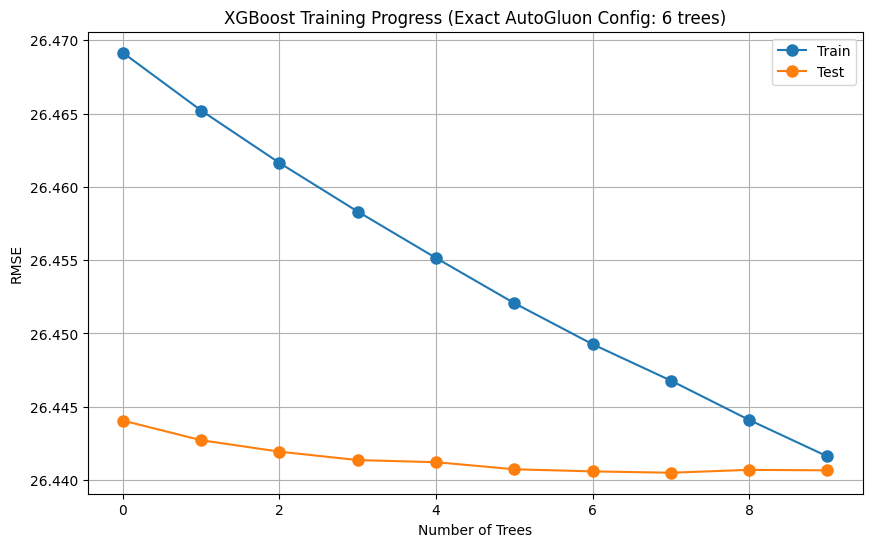


模型性能评估：
训练集 R²: 0.0024
测试集 R²: 0.0003


In [32]:
#用合并数据训练
model_exact = XGBRegressor(
    n_estimators=10,
    learning_rate=0.1,
    objective='reg:squarederror',
    booster='gbtree',
    n_jobs=-1,
    random_state=42,
    eval_metric='rmse'
)

# 训练模型
eval_set = [(X_train, y_train), (X_test, y_test)]
model_exact.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=True
)

# 获取并绘制结果
results_exact = model_exact.evals_result()

plt.figure(figsize=(10, 6))
plt.plot(results_exact['validation_0']['rmse'], 'o-', label='Train', markersize=8)
plt.plot(results_exact['validation_1']['rmse'], 'o-', label='Test', markersize=8)
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')
plt.title('XGBoost Training Progress (Exact AutoGluon Config: 6 trees)')
plt.legend()
plt.grid(True)
plt.show()

train_r2 = model_exact.score(X_train, y_train)
test_r2 = model_exact.score(X_test, y_test)

print(f"\n模型性能评估：")
print(f"训练集 R²: {train_r2:.4f}")
print(f"测试集 R²: {test_r2:.4f}")

In [ ]:
#autogluon超参数树训练模型，R^2分数表现极差（越接近1越好）
#判定数据的特征和label相关性极差，模型基本上在瞎猜